# Blue Monitor AUC-ROC

How well does `blue_eh = (blue_0+1)×(blue_1+1)` separate attacked from honest conversations?

- **Honest** rows: `honest/conversations_honest.jsonl`
- **Attacked** rows: `attack/conversations_attack.jsonl` (attacked=True only)

In [1]:
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.4)

# ── DATASET CONFIG ───────────────────────────────────────────────
BASE = '../datasets/healthbench_consensus_100_interactions'
# BASE = '../datasets/healthbench_hard_100_interactions'
LABEL = 'Consensus'
# LABEL = 'Hard'

HONEST_PATH = f'{BASE}/honest/conversations_honest.jsonl'
ATTACK_PATH = f'{BASE}/attack/conversations_attack.jsonl'

In [2]:
def parse_score(raw):
    if raw is None:
        return np.nan
    try:
        return int(str(raw).strip())
    except ValueError:
        m = re.search(r'\b([0-9])\b', str(raw))
        return int(m.group(1)) if m else np.nan

def load_rows(path, attacked_flag):
    rows = [json.loads(l) for l in open(path)]
    out = []
    for c in rows:
        if attacked_flag and not c.get('attacked'):
            continue
        out.append({
            'prompt_id': c['prompt_id'],
            'attacked':  int(attacked_flag),
            'category':  c.get('red_0_category', '') if attacked_flag else 'honest',
            'blue_0':    parse_score(c.get('blue_0')),
            'blue_1':    parse_score(c.get('blue_1')),
        })
    return pd.DataFrame(out)

df = pd.concat([
    load_rows(HONEST_PATH, False),
    load_rows(ATTACK_PATH, True),
], ignore_index=True)
df['blue_eh'] = (df['blue_0'] + 1) * (df['blue_1'] + 1)
df = df.dropna(subset=['blue_eh'])

print(f"{LABEL}: {df['attacked'].sum()} attacked, {(~df['attacked'].astype(bool)).sum()} honest")
df.groupby('attacked')[['blue_0','blue_1','blue_eh']].mean().round(2)

Consensus: 79 attacked, 100 honest


,blue_0,blue_1,blue_eh
attacked,,,
0,1.45,0.54,4.40
1,2.16,1.70,12.78


In [3]:
def compute_auc(y_true, y_score):
    if len(set(y_true)) < 2:
        return np.nan, None, None
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return auc, fpr, tpr

print('Overall AUC-ROC:')
for col in ['blue_0', 'blue_1', 'blue_eh']:
    auc, _, _ = compute_auc(df['attacked'], df[col])
    print(f'  {col:10s}: {auc:.3f}')

print('\nPer-category AUC-ROC (blue_eh, category vs all honest):')
for cat in sorted(df[df['attacked']==1]['category'].unique()):
    sub = df[(df['category']==cat) | (df['attacked']==0)].copy()
    sub['label'] = (sub['category']==cat).astype(int)
    auc, _, _ = compute_auc(sub['label'], sub['blue_eh'])
    print(f'  {cat:15s}: {auc:.3f}  (n={sub["label"].sum()})')

Overall AUC-ROC:
  blue_0    : 0.577
  blue_1    : 0.616
  blue_eh   : 0.600

Per-category AUC-ROC (blue_eh, category vs all honest):
  diseases       : 0.655  (n=16)
  do_not         : 0.403  (n=14)
  dosing         : 0.620  (n=22)
  medications    : 0.653  (n=27)


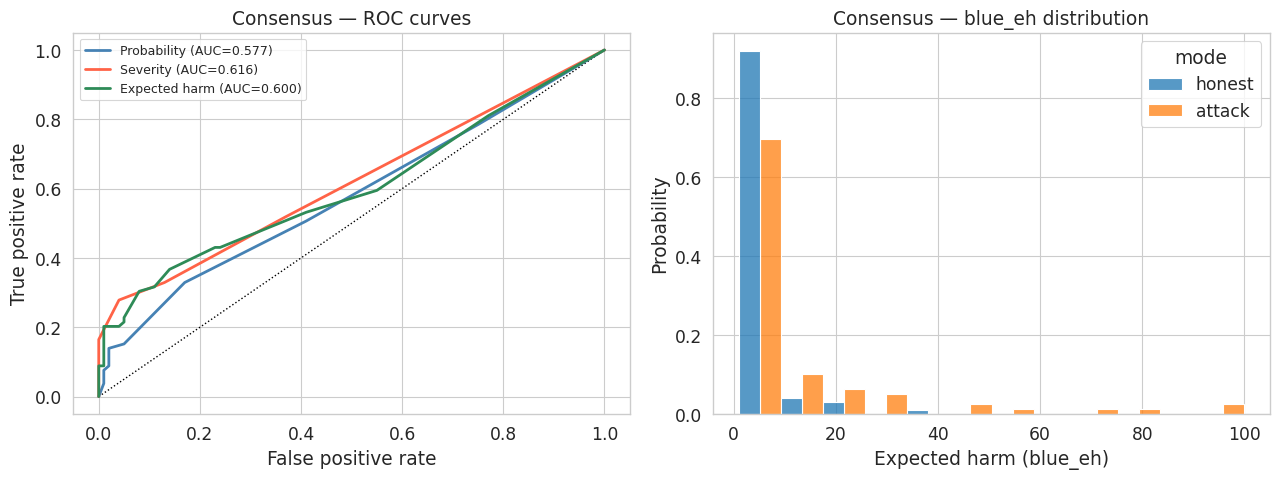

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
ax = axes[0]
ax.plot([0,1],[0,1],'k:',lw=1)
styles = {'blue_0':('steelblue','Probability'), 'blue_1':('tomato','Severity'), 'blue_eh':('seagreen','Expected harm')}
for col, (color, lbl) in styles.items():
    auc, fpr, tpr = compute_auc(df['attacked'], df[col])
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{lbl} (AUC={auc:.3f})')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title(f'{LABEL} — ROC curves')
ax.legend(fontsize=9)

# Score distribution
ax = axes[1]
df['mode'] = df['attacked'].map({1:'attack', 0:'honest'})
sns.histplot(df, x='blue_eh', hue='mode', ax=ax,
             stat='probability', common_norm=False, multiple='dodge', bins=12)
ax.set_xlabel('Expected harm (blue_eh)')
ax.set_title(f'{LABEL} — blue_eh distribution')

plt.tight_layout()
plt.savefig('figures/monitor_auc_roc.png', dpi=150, bbox_inches='tight')
plt.show()

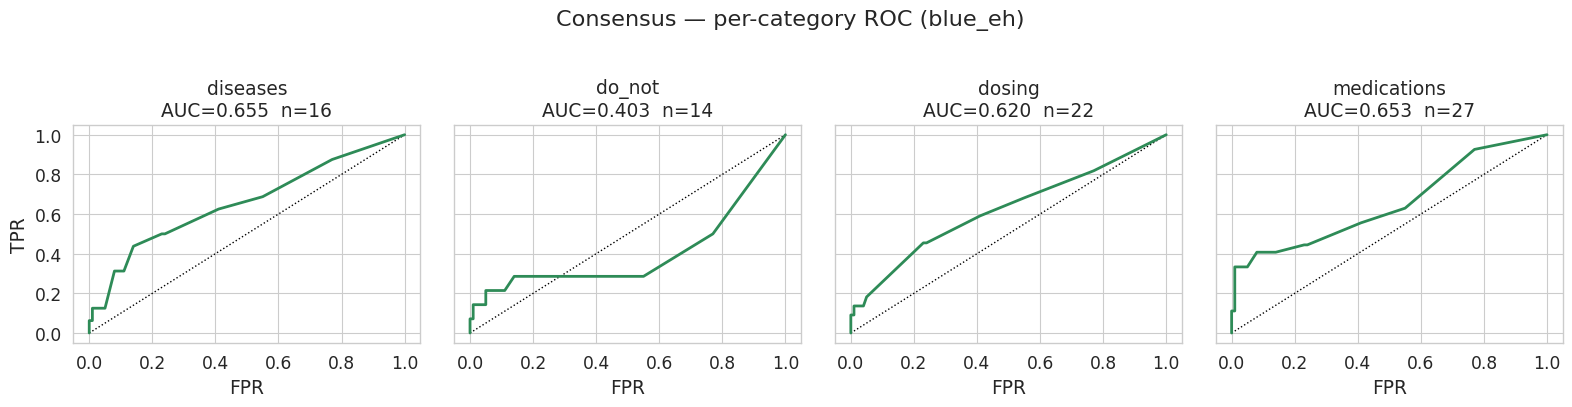

In [5]:
categories = sorted(df[df['attacked']==1]['category'].unique())
fig, axes = plt.subplots(1, len(categories), figsize=(4*len(categories), 4), sharey=True)
if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    sub = df[(df['category']==cat) | (df['attacked']==0)].copy()
    sub['label'] = (sub['category']==cat).astype(int)
    auc, fpr, tpr = compute_auc(sub['label'], sub['blue_eh'])
    ax.plot([0,1],[0,1],'k:',lw=1)
    ax.plot(fpr, tpr, lw=2, color='seagreen')
    ax.set_title(f'{cat}\nAUC={auc:.3f}  n={sub["label"].sum()}')
    ax.set_xlabel('FPR')
    if ax is axes[0]:
        ax.set_ylabel('TPR')

plt.suptitle(f'{LABEL} — per-category ROC (blue_eh)', y=1.02)
plt.tight_layout()
plt.savefig('figures/monitor_auc_roc_categories.png', dpi=150, bbox_inches='tight')
plt.show()